In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from scipy.interpolate import CubicSpline

### Task 1A: EDA

Notice all sorts of properties of the dataset: how many records are there, how many
attributes, what kinds of attributes are there, ranges of values, distribution of values,
relationships between attributes, missing values, and so on. A table is often a suitable
way of showing such properties of a dataset. Notice if something is interesting (to you,
or in general), make sure you write it down if you find something worth mentioning.

Make various plots of the data. Is there something interesting worth reporting? Re-
port the figures, discuss what is in them. What meaning do those bars, lines, dots, etc.
convey? Please select essential and interesting plots for discussion, as you have limited
space for reporting your findings

In [2]:
df = pl.read_csv("dataset_mood_smartphone.csv", infer_schema_length=0).with_columns(
    pl.col("time").str.to_datetime("%Y-%m-%d %H:%M:%S%.3f", strict=False),
    pl.col("value").cast(pl.Float64, strict=False),
).with_columns( pl.col("time").dt.date().alias("date"),
    pl.col("time").dt.time().alias("time")).drop("")

In [3]:
df.head(10)

id,time,variable,value,date
str,time,str,f64,date
"""AS14.01""",13:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",15:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",18:00:00,"""mood""",6.0,2014-02-26
"""AS14.01""",21:00:00,"""mood""",7.0,2014-02-26
"""AS14.01""",09:00:00,"""mood""",6.0,2014-02-27
"""AS14.01""",12:00:00,"""mood""",6.0,2014-02-27
"""AS14.01""",15:00:00,"""mood""",7.0,2014-02-27
"""AS14.01""",09:00:00,"""mood""",6.0,2014-03-21
"""AS14.01""",11:00:00,"""mood""",6.0,2014-03-21


In [4]:
df.select(pl.col("time", "variable", "value", "date")).describe()

statistic,time,variable,value,date
str,str,str,f64,str
"""count""","""376912""","""376912""",376710.0,"""376912"""
"""null_count""","""0""","""0""",202.0,"""0"""
"""mean""","""14:56:50.210806""",null,40.665313,"""2014-04-15 14:04:26.748737"""
"""std""",null,null,273.726007,null
"""min""","""00:00:00""","""activity""",-82798.871,"""2014-02-17"""
"""25%""","""11:25:11.648000""",null,2.025,"""2014-04-03"""
"""50%""","""15:21:00.812000""",null,7.029,"""2014-04-15"""
"""75%""","""19:17:59.874000""",null,29.356,"""2014-04-27"""
"""max""","""23:59:59.946000""","""sms""",33960.246,"""2014-06-09"""


In [5]:
#Each variable has its own range of values. To ensure an appropriate comparison, the value summary statistics are calculated per variable type 

summary = df.group_by("variable").agg(
    pl.col("value").count().alias("count"),
    pl.col("value").null_count().alias("nulls"),
    pl.col("value").mean().alias("mean"),
    pl.col("value").median().alias("median"),
    pl.col("value").std().alias("std"),
    pl.col("value").min().alias("min"),
    pl.col("value").quantile(0.25).alias("q25"),
    pl.col("value").quantile(0.75).alias("q75"),
    pl.col("value").max().alias("max"),
).sort("variable")



In [6]:
summary

variable,count,nulls,mean,median,std,min,q25,q75,max
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""activity""",22965,0,0.115958,0.021739,0.186946,0.0,0.0,0.158333,1.0
"""appCat.builtin""",91288,0,18.538262,4.038,415.989243,-82798.871,2.02,9.922,33960.246
"""appCat.communication""",74276,0,43.343792,16.2255,128.91275,0.006,5.218,45.474,9830.777
"""appCat.entertainment""",27125,0,37.57648,3.391,262.960476,-0.011,1.334,14.922,32148.677
"""appCat.finance""",939,0,21.755251,8.026,39.218361,0.131,4.074,20.212,355.513
…,…,…,…,…,…,…,…,…,…
"""circumplex.arousal""",5597,46,-0.098624,0.0,1.051868,-2.0,-1.0,1.0,2.0
"""circumplex.valence""",5487,156,0.687808,1.0,0.671298,-2.0,0.0,1.0,2.0
"""mood""",5641,0,6.992555,7.0,1.032769,1.0,7.0,8.0,10.0


In [7]:
pl.Config.set_tbl_rows(100)
summary

variable,count,nulls,mean,median,std,min,q25,q75,max
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""activity""",22965,0,0.115958,0.021739,0.186946,0.0,0.0,0.158333,1.0
"""appCat.builtin""",91288,0,18.538262,4.038,415.989243,-82798.871,2.02,9.922,33960.246
"""appCat.communication""",74276,0,43.343792,16.2255,128.91275,0.006,5.218,45.474,9830.777
"""appCat.entertainment""",27125,0,37.57648,3.391,262.960476,-0.011,1.334,14.922,32148.677
"""appCat.finance""",939,0,21.755251,8.026,39.218361,0.131,4.074,20.212,355.513
"""appCat.game""",813,0,128.391615,43.168,327.145246,1.003,14.148,123.625,5491.793
"""appCat.office""",5642,0,22.578892,3.106,449.601382,0.003,2.004,8.044,32708.818
"""appCat.other""",7650,0,25.810839,10.028,112.781355,0.014,7.019,16.835,3892.038
"""appCat.social""",19145,0,72.401906,28.466,261.551846,0.094,9.03,75.372,30000.906


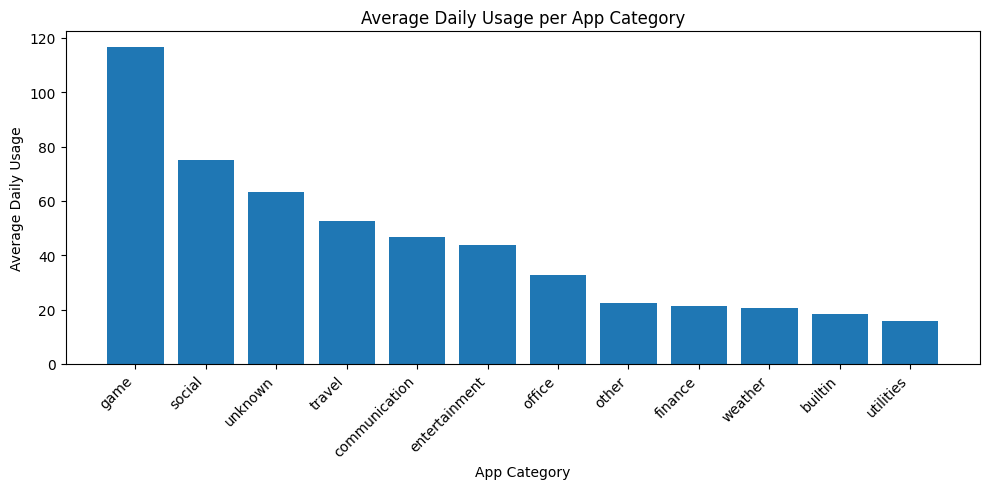

In [8]:
app_avg = (
    df.filter(pl.col("variable").str.starts_with("appCat"))
    .group_by(["variable", "date"])
    .agg(pl.col("value").mean().alias("daily_avg"))
    .group_by("variable")
    .agg(pl.col("daily_avg").mean().alias("avg_daily_usage"))
    .sort("avg_daily_usage", descending=True)
)

labels = [v.replace("appCat.", "") for v in app_avg["variable"].to_list()]
values = app_avg["avg_daily_usage"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values)
ax.set_xlabel("App Category")
ax.set_ylabel("Average Daily Usage")
ax.set_title("Average Daily Usage per App Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
def avg_by(group_col):
    return (
        app.group_by([group_col, "date"])
        .agg(pl.col("value").mean().alias("daily_avg"))
        .group_by(group_col)
        .agg(pl.col("daily_avg").mean().alias("avg_value"))
        .sort(group_col)
    )


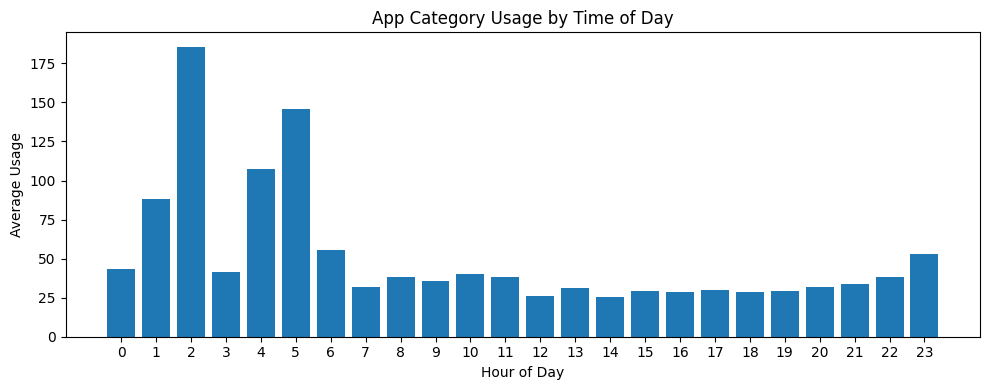

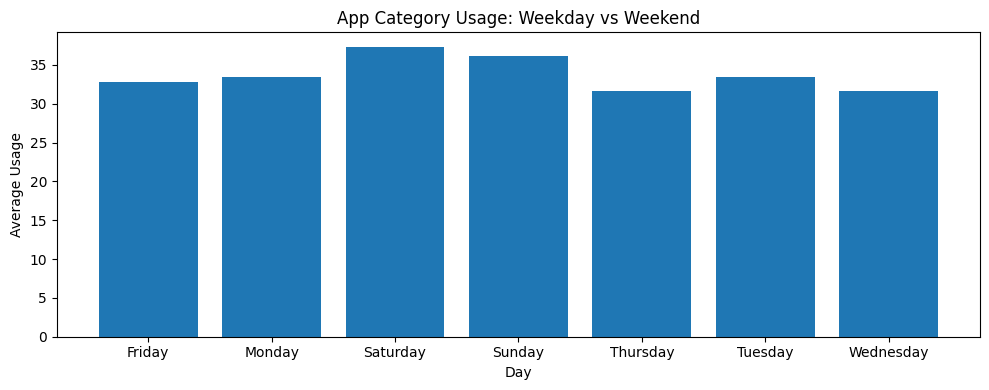

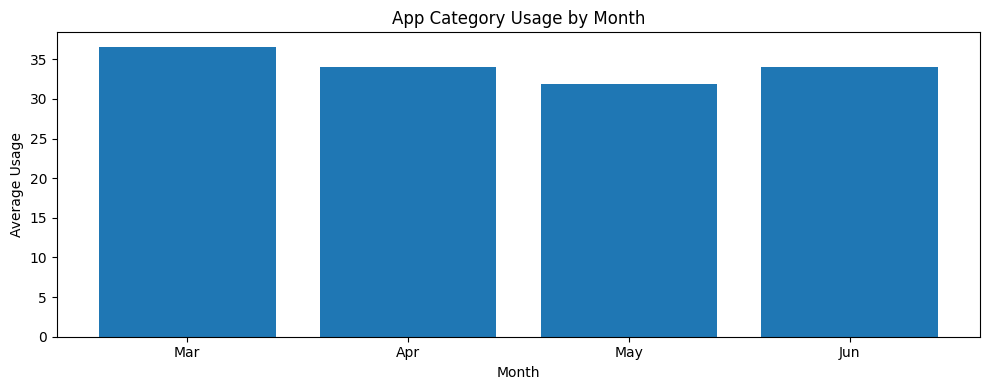

In [10]:

day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

app = (
    df.filter(pl.col("variable").str.starts_with("appCat"))
    .with_columns(
        pl.col("time").dt.hour().alias("hour"),
        pl.col("date").dt.weekday().alias("weekday"),
        pl.col("date").dt.month().alias("month"),
    )
    .with_columns(
        pl.col("weekday").replace_strict(
            {i+1: name for i, name in enumerate(day_names)}
        ).alias("day_name")
    )
)

by_hour = avg_by("hour")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour["hour"].to_list(), by_hour["avg_value"].to_list())
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage by Time of Day")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

by_daytype = avg_by("day_name")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_daytype["day_name"].to_list(), by_daytype["avg_value"].to_list())
ax.set_xlabel("Day")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage: Weekday vs Weekend")
plt.tight_layout()
plt.show()

by_month = avg_by("month")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
labels = [month_labels[m - 1] for m in by_month["month"].to_list()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, by_month["avg_value"].to_list())
ax.set_xlabel("Month")
ax.set_ylabel("Average Usage")
ax.set_title("App Category Usage by Month")
plt.tight_layout()
plt.show()

In [11]:
# Number of unique patients
print(f"Unique patients: {df['id'].n_unique()}")
print(f"Total records: {len(df)}")
print(f"Unique variables: {df['variable'].n_unique()}")

# Date range per patient
patient_summary = df.group_by("id").agg(
    pl.col("date").min().alias("start_date"),
    pl.col("date").max().alias("end_date"),
    pl.col("date").n_unique().alias("active_days"),
    pl.len().alias("total_records"),
).sort("id")

patient_summary = patient_summary.with_columns(
    (pl.col("end_date") - pl.col("start_date")).dt.total_days().alias("span_days")
)

patient_summary


Unique patients: 27
Total records: 376912
Unique variables: 19


id,start_date,end_date,active_days,total_records,span_days
str,date,date,u32,u32,i64
"""AS14.01""",2014-02-17,2014-05-05,72,21999,77
"""AS14.02""",2014-02-17,2014-04-25,68,14581,67
"""AS14.03""",2014-02-17,2014-05-08,77,14425,80
"""AS14.05""",2014-02-18,2014-05-05,70,15745,76
"""AS14.06""",2014-02-17,2014-05-08,74,18092,80
"""AS14.07""",2014-03-17,2014-05-05,50,16045,49
"""AS14.08""",2014-02-17,2014-05-05,67,7902,77
"""AS14.09""",2014-02-17,2014-05-05,71,10886,77
"""AS14.12""",2014-02-19,2014-05-05,67,17311,75


In [12]:
# Records per variable
variable_counts = df.group_by("variable").agg(
    pl.len().alias("total_records"),
    pl.col("id").n_unique().alias("num_patients"),
    pl.col("value").null_count().alias("null_values"),
).sort("variable")

variable_counts

variable,total_records,num_patients,null_values
str,u32,u32,u32
"""activity""",22965,27,0
"""appCat.builtin""",91288,27,0
"""appCat.communication""",74276,27,0
"""appCat.entertainment""",27125,27,0
"""appCat.finance""",939,15,0
"""appCat.game""",813,15,0
"""appCat.office""",5642,22,0
"""appCat.other""",7650,27,0
"""appCat.social""",19145,27,0


- 27 patients, most tracked from mid Feb to early May 2024 with a few exceptions.

- Gap between span and active days.

- Nulls show that some vars have no records for certain days. Missing here means absent rows

- Weather,, finance, game are very sparse categories



In [13]:
# grid of (patient, date, variable)
all_dates = df.select("id", "date").unique()
all_vars = df.select("variable").unique()

daily_presence = (
    df.group_by(["id", "date", "variable"])
    .agg(pl.len().alias("n_records"))
    .pivot(on="variable", index=["id", "date"], values="n_records")
)

key_vars = ["mood", "circumplex.arousal", "circumplex.valence", 
            "activity", "screen", "call", "sms"]

missing_pct = []
for var in key_vars:
    for pid in sorted(df["id"].unique().to_list()):
        patient_dates = daily_presence.filter(pl.col("id") == pid)
        total_days = len(patient_dates)
        if var in patient_dates.columns:
            present = patient_dates[var].drop_nulls().len()
        else:
            present = 0
        missing_pct.append({"id": pid, "variable": var, 
                           "missing_pct": round((1 - present/total_days) * 100, 1)})

missing_df = pl.DataFrame(missing_pct)

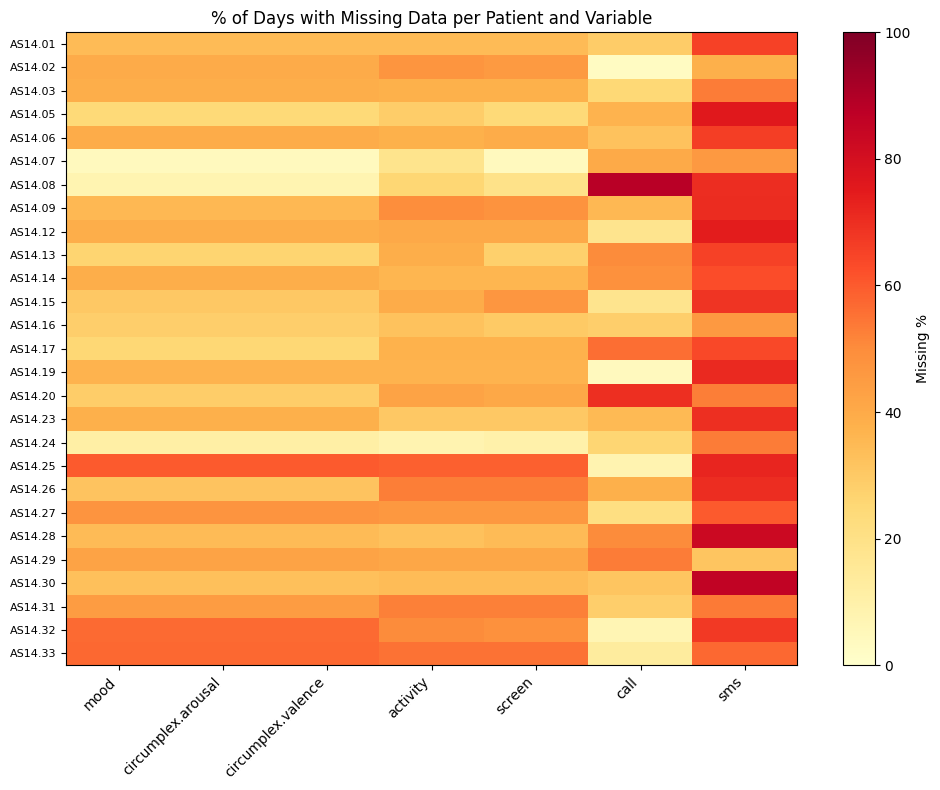

In [14]:
pivot = missing_df.pivot(on="variable", index="id", values="missing_pct").sort("id")
patient_ids = pivot["id"].to_list()
matrix = pivot.drop("id").to_numpy()
col_names = [c for c in pivot.columns if c != "id"]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(col_names)))
ax.set_xticklabels(col_names, rotation=45, ha="right")
ax.set_yticks(range(len(patient_ids)))
ax.set_yticklabels(patient_ids, fontsize=8)
ax.set_title("% of Days with Missing Data per Patient and Variable")
plt.colorbar(im, label="Missing %")
plt.tight_layout()
plt.show()

- Mood, arousal and valence present in most records

- Call and SMS are very sparse. Missing likely means no calls or texts that day since event-based

- AS14.25 almost everything is missing except screend data. AS14.33 is not great either

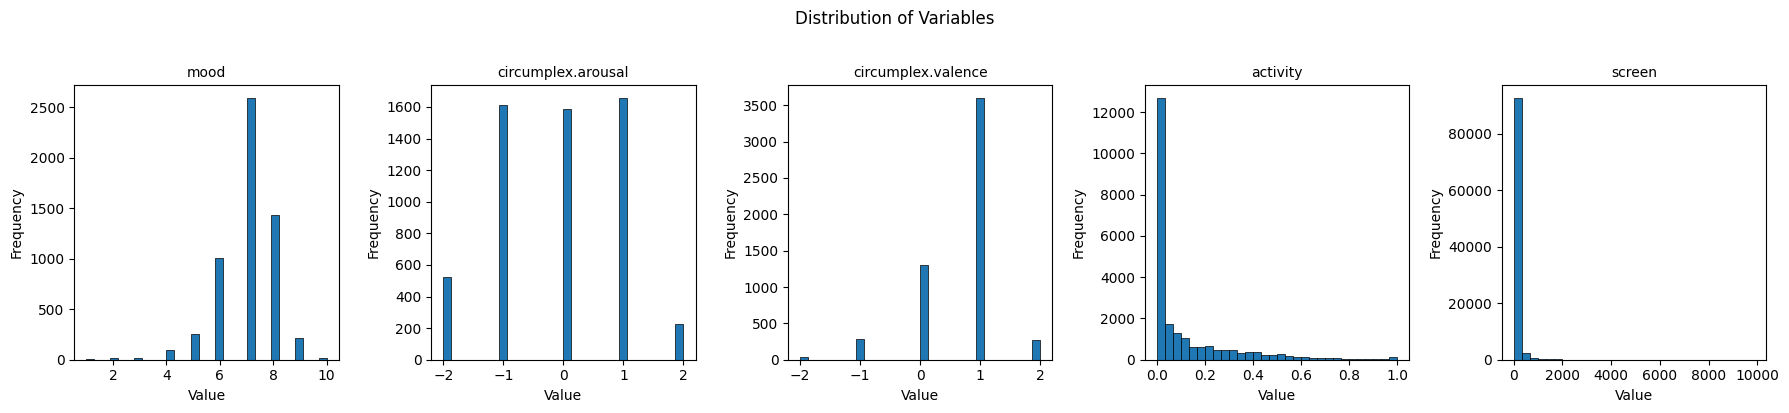

In [15]:
key_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity", "screen"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, var in zip(axes, key_vars):
    data = df.filter(pl.col("variable") == var)["value"].drop_nulls().to_list()
    ax.hist(data, bins=30, edgecolor="black", linewidth=0.5)
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Variables", y=1.02)
plt.tight_layout()
plt.show()

- Mood is roughly normal with a left skew. Low vals are rare

- Arousal and valence in the [-2,2] scale. Valence is positive skewed.

- Activity heavily right skewed. Most vals near 0 with a long tail. 

- Screen seems a bit problematic. We should look at extreme vals of continuous screen time more closely

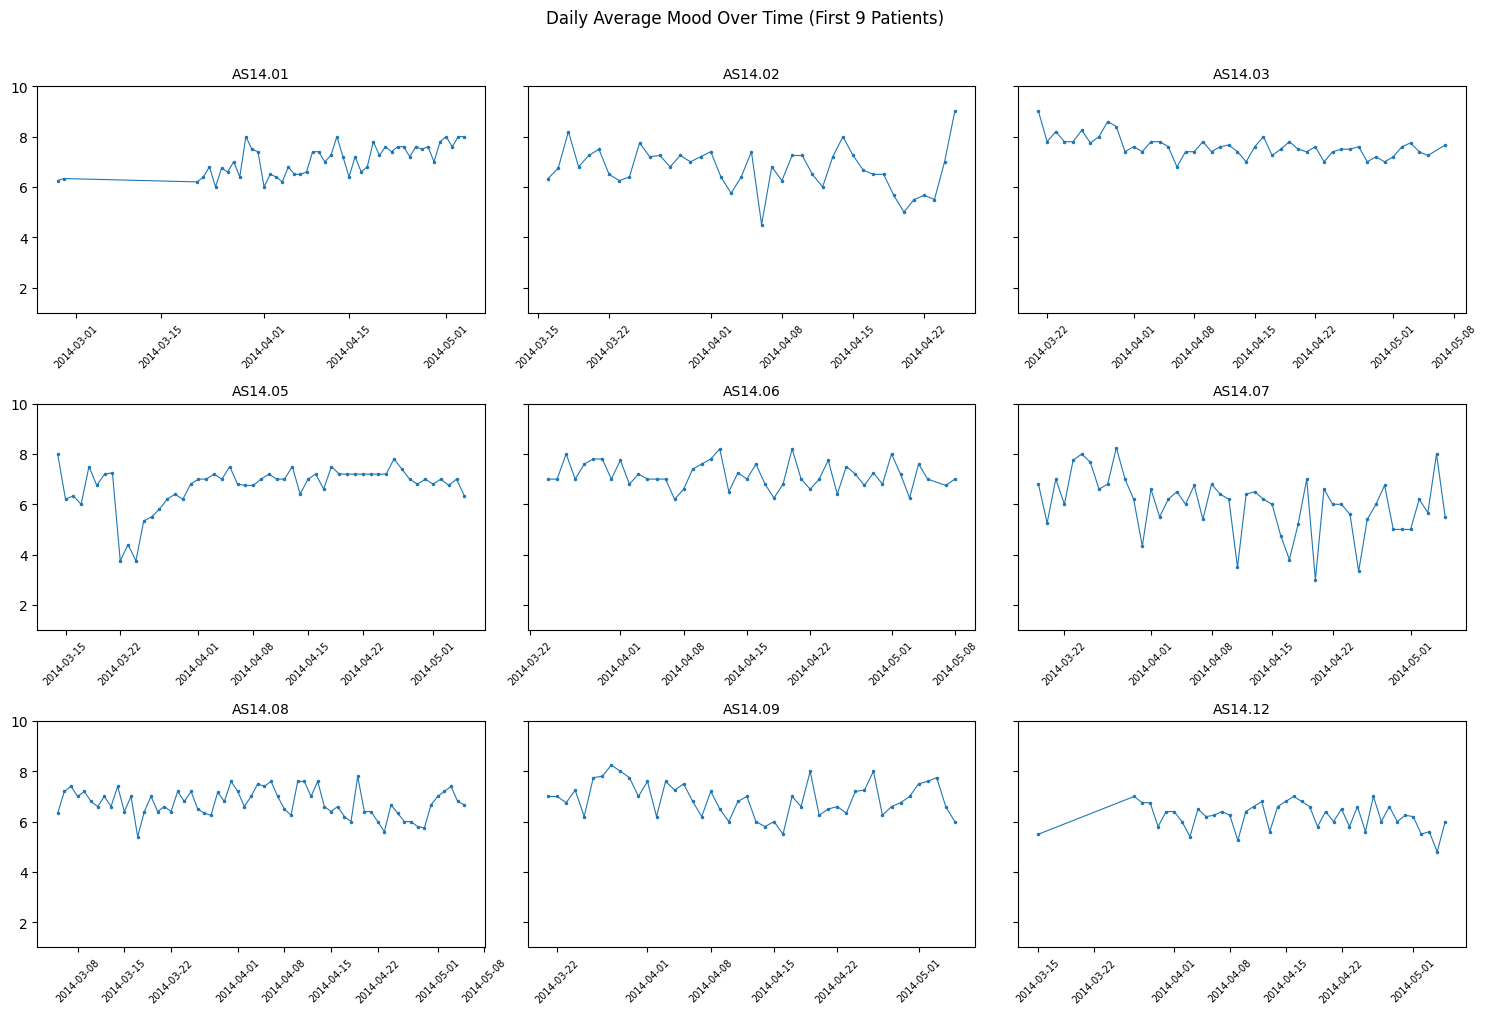

In [16]:
mood_data = df.filter(pl.col("variable") == "mood").drop_nulls("value")

# Daily average mood per patient
daily_mood = (
    mood_data.group_by(["id", "date"])
    .agg(pl.col("value").mean().alias("daily_mood"))
    .sort("date")
)
sample_patients = sorted(daily_mood["id"].unique().to_list())[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=False, sharey=True)
axes = axes.flatten()

for ax, pid in zip(axes, sample_patients):
    patient = daily_mood.filter(pl.col("id") == pid).sort("date")
    ax.plot(patient["date"].to_list(), patient["daily_mood"].to_list(), 
            marker=".", markersize=3, linewidth=0.8)
    ax.set_title(pid, fontsize=10)
    ax.set_ylim(1, 10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("Daily Average Mood Over Time (First 9 Patients)", y=1.01)
plt.tight_layout()
plt.show()

- This seems relatively stable. 

- Example: AS14.01 has a missing two week period. We need to deal with this per the assigmnent. 

- Obvious autocorrelation between so time series for imputation should be ok.

/Users/kimonanagnostopoulos/projects/academic/Data-Mining/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/kimonanagnostopoulos/projects/academic/Data-Mining/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


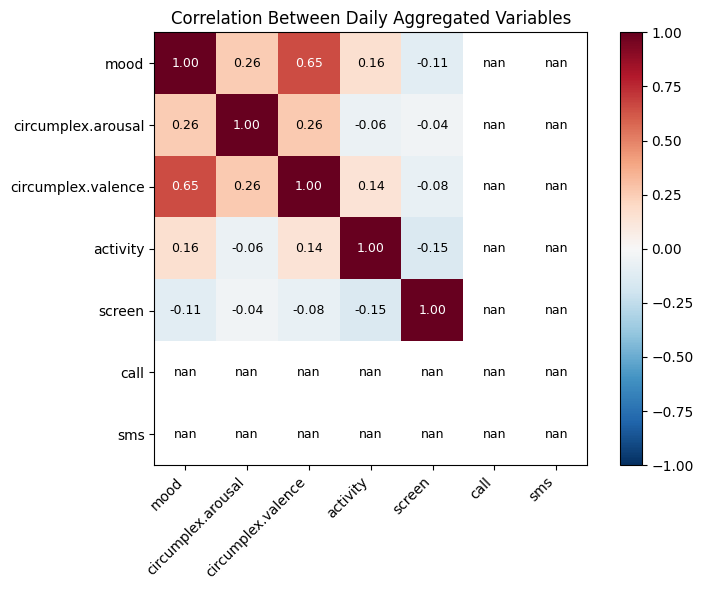

In [17]:
# daily level per patient per variable
daily = (
    df.group_by(["id", "date", "variable"])
    .agg(pl.col("value").mean().alias("daily_value"))
    .pivot(on="variable", index=["id", "date"], values="daily_value")
)

corr_vars = ["mood", "circumplex.arousal", "circumplex.valence", 
             "activity", "screen", "call", "sms"]
corr_vars = [v for v in corr_vars if v in daily.columns]

# correlation
data = np.column_stack([daily[v].to_numpy() for v in corr_vars])
mask = ~np.isnan(data).any(axis=1)
corr_matrix = np.corrcoef(data[mask], rowvar=False)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticks(range(len(corr_vars)))
ax.set_yticklabels(corr_vars)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr_matrix[i, j]:.2f}", 
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_matrix[i, j]) > 0.5 else "black")

ax.set_title("Correlation Between Daily Aggregated Variables")
plt.colorbar(im)
plt.tight_layout()
plt.show()

- Modd and variance have strongest correlation. Valence makes sense to be close to mood

- Mood and arousal have moderate correlation.

- Screen time has weak negative correlation with mood and activity

- Activity and mood have weak positive correlation

### Task 1B: Data Cleaning

Apply an approach to remove extreme and incorrect values from your dataset. Describe
what your approach is, why you consider that to be a good approach, and describe what
the result of applying the approach is.

*Basic:* Impute the missing values using two different approaches. Describe the ap-
proaches and study the impact of applying them to your data. Argue which one of
the two approaches would be most suitable and select that one to form your cleaned
dataset. Also base yourself on scientific literature for making your choice.

*Advanced:* The advanced dataset contains a number of time series, select two ap-
proaches to impute missing values that are logical for such time series and argue for
one of them based on the insights you gain, base yourself on insight from the data, log-
ical reasoning and scientific literature. Also consider what to do with prolonged periods
of missing data in a time series

In [18]:
# Domain-based bounds with IQR for vars w/o fixed ranges

# From table 2 some vars have fixed ranges. So we can use those first.
# For vars without a strict range, we can use IQR to identify outliers.

domain_bounds = {
    "mood": (1, 10),
    "circumplex.arousal": (-2, 2),
    "circumplex.valence": (-2, 2),
    "activity": (0, 1),
}

# out-of-range value count
for var, (lo, hi) in domain_bounds.items():
    subset = df.filter(pl.col("variable") == var)
    out_of_range = subset.filter(
        (pl.col("value") < lo) | (pl.col("value") > hi)
    )
    print(f"{var}: {len(out_of_range)} values outside [{lo}, {hi}]")

mood: 0 values outside [1, 10]
circumplex.arousal: 0 values outside [-2, 2]
circumplex.valence: 0 values outside [-2, 2]
activity: 0 values outside [0, 1]


For screen the distribution seemed a bit problematic so checking with quartile filter

In [19]:
screen = df.filter(pl.col("variable") == "screen")["value"].drop_nulls()
q1 = screen.quantile(0.25)
q3 = screen.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr  # using 3x IQR for now
print(f"\nScreen IQR analysis: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"Upper fence (3x IQR): {upper_fence:.1f}")
print(f"Values above fence: {screen.filter(screen > upper_fence).len()}")
print(f"Max value: {screen.max()}")


Screen IQR analysis: Q1=5.3, Q3=62.5, IQR=57.2
Upper fence (3x IQR): 234.2
Values above fence: 5957
Max value: 9867.00699996948


In [20]:
# Distribution check
print("Screen value percentiles:")
for p in [0.90, 0.95, 0.99, 0.995, 0.999]:
    val = screen.quantile(p)
    print(f"  {p*100:.1f}th percentile: {val:.1f}")

print(f"\nTotal screen records: {len(screen)}")
print(f"Values > 500: {screen.filter(screen > 500).len()}")
print(f"Values > 1000: {screen.filter(screen > 1000).len()}")
print(f"Values > 3600: {screen.filter(screen > 3600).len()}")

Screen value percentiles:
  90.0th percentile: 153.0
  95.0th percentile: 278.8
  99.0th percentile: 915.4
  99.5th percentile: 1383.4
  99.9th percentile: 3463.4

Total screen records: 96578
Values > 500: 2277
Values > 1000: 815
Values > 3600: 91


We can set some type of threshold at 3600 but not sure here.

In [21]:
before_count = len(df)

# NOTE: emove screen values > 3600 (treat as sensor errors) for now
df_clean = df.filter(
    ~((pl.col("variable") == "screen") & (pl.col("value") > 3600))
)

# mark the null values in arousal and valence 

after_count = len(df_clean)
print(f"Records before: {before_count}")
print(f"Records removed: {before_count - after_count}")
print(f"Records after: {after_count}")
print(f"Percentage removed: {(before_count - after_count) / before_count * 100:.2f}%")

Records before: 376912
Records removed: 91
Records after: 376821
Percentage removed: 0.02%


Prepare data for imputation

In [22]:
# Aggregate to daily level per patient per variable
daily = (
    df_clean.group_by(["id", "date", "variable"])
    .agg(pl.col("value").mean().alias("value"))
)

# Event-based variables: zero-fill
event_vars = ["call", "sms"]
impute_vars = ["mood", "circumplex.arousal", "circumplex.valence", 
               "activity", "screen"]

# Build full date grid per patient
full_grid_parts = []
for pid in sorted(df_clean["id"].unique().to_list()):
    p_dates = daily.filter(pl.col("id") == pid)["date"]
    dates = pl.date_range(p_dates.min(), p_dates.max(), eager=True).alias("date")
    for var in impute_vars + event_vars:
        full_grid_parts.append(pl.DataFrame({
            "id": [pid] * len(dates),
            "date": dates,
            "variable": [var] * len(dates),
        }))

daily_full = pl.concat(full_grid_parts).join(daily, on=["id", "date", "variable"], how="left")

# Zero-fill event variables
daily_full = daily_full.with_columns(
    pl.when(pl.col("variable").is_in(event_vars) & pl.col("value").is_null())
    .then(0.0)
    .otherwise(pl.col("value"))
    .alias("value")
)

print(f"Total daily records: {len(daily_full)}")
print(f"Missing in impute vars: {daily_full.filter(pl.col('variable').is_in(impute_vars))['value'].null_count()}")

Total daily records: 15078
Missing in impute vars: 4573


For now we do:

- Linear interpolation: Computationally cheap

- Spline interpolation: Capture non-linear transitions between known vals.

For big data gaps, we can exclude them from training. Should not interpolate across long data stretches on a health dataset.




Some possible references:

    https://pmc.ncbi.nlm.nih.gov/articles/PMC12392262/

    https://ar5iv.labs.arxiv.org/html/2202.03721

    https://www.nature.com/articles/s41598-026-39035-z


In [23]:
def find_gap_lengths(values):
    """Find consecutive NaN gap lengths."""
    is_null = np.isnan(values)
    gaps = []
    count = 0
    for i, v in enumerate(is_null):
        if v:
            count += 1
        else:
            if count > 0:
                gaps.append((i - count, count))
            count = 0
    if count > 0:
        gaps.append((len(values) - count, count))
    return gaps

def impute_linear(values, max_gap=3):
    """Linear interpolation, skipping gaps > max_gap days."""
    result = values.copy()
    gaps = find_gap_lengths(values)

    nans = np.isnan(result)
    if nans.all() or (~nans).sum() < 2: # 
        return result
    x_known = np.where(~nans)[0]
    y_known = result[~nans]
    x_missing = np.where(nans)[0]
    if len(x_missing) > 0:
        result[x_missing] = np.interp(x_missing, x_known, y_known)
 
    for start, length in gaps:
        if length > max_gap:
            result[start:start+length] = np.nan
    return result

def impute_spline(values, max_gap=3):
    """Cubic spline interpolation, skipping gaps > max_gap days."""
    result = values.copy()
    gaps = find_gap_lengths(values)
    nans = np.isnan(result)
    if nans.all() or (~nans).sum() < 5: #NOTE: Max gap is set 5 but we can change it
        return result
    x_known = np.where(~nans)[0]
    y_known = result[~nans]
    x_missing = np.where(nans)[0]
    if len(x_missing) > 0:
        cs = CubicSpline(x_known, y_known, extrapolate=False)
        result[x_missing] = cs(x_missing)

    for start, length in gaps:
        if length > max_gap:
            result[start:start+length] = np.nan
    return result

Finding a threshold value

In [27]:
all_gaps = []
for pid in sorted(daily_full["id"].unique().to_list()):
    for var in impute_vars:
        subset = (daily_full
                  .filter((pl.col("id") == pid) & (pl.col("variable") == var))
                  .sort("date"))
        values = subset["value"].to_numpy().astype(float)
        gaps = find_gap_lengths(values)
        for start, length in gaps:
            all_gaps.append({"id": pid, "variable": var, "gap_length": length})

# threshold check
for threshold in [3, 5, 7, 14, 21, 30]:
    fillable = sum(g["gap_length"] for g in all_gaps if g["gap_length"] <= threshold)
    unfillable = sum(g["gap_length"] for g in all_gaps if g["gap_length"] > threshold)
    n_gaps = sum(1 for g in all_gaps if g["gap_length"] <= threshold)
    print(f"Threshold {threshold:2d}d: fill {fillable:5d} values ({n_gaps:3d} gaps), "
          f"leave {unfillable:5d} as NaN")

Threshold  3d: fill   160 values (134 gaps), leave  4413 as NaN
Threshold  5d: fill   197 values (142 gaps), leave  4376 as NaN
Threshold  7d: fill   227 values (147 gaps), leave  4346 as NaN
Threshold 14d: fill   331 values (158 gaps), leave  4242 as NaN
Threshold 21d: fill   487 values (167 gaps), leave  4086 as NaN
Threshold 30d: fill  1216 values (196 gaps), leave  3357 as NaN


**NOTE:** Think we can measure autocorrelation to justify a suitable gap for the threshold but I need to look into this.